# 🏦 Term Deposit Subscription Prediction (Bank Marketing)
### Predicting Customer Response to Marketing Campaigns Using Classification & Explainable AI

---

**Objective:** Predict whether a bank customer will subscribe to a term deposit based on demographic, financial, and campaign-related features.

**Dataset:** UCI Bank Marketing Dataset — 11,162 records with 17 features from direct marketing campaigns of a Portuguese banking institution.

**Methodology:**
1. Data exploration & quality assessment
2. Deep EDA with interactive visualizations — understanding customer segments
3. Feature encoding (One-Hot, Label, Ordinal) & engineering
4. Class imbalance handling with SMOTE
5. Model development: **Logistic Regression**, **Random Forest**, **XGBoost**, **LightGBM**
6. Evaluation: Confusion Matrix, F1-Score, ROC-AUC, Precision-Recall curves
7. **Explainable AI (XAI)** — SHAP global/local explanations + LIME individual predictions

**Tech Stack:** Python · Pandas · Plotly · scikit-learn · XGBoost · LightGBM · SHAP · LIME · imbalanced-learn

In [2]:
# Install required packages
!pip install shap lime lightgbm imbalanced-learn --quiet

In [3]:
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

In [4]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
import plotly.figure_factory as ff
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)
from imblearn.over_sampling import SMOTE

# Explainability
import shap
import lime
import lime.lime_tabular

# Config
pio.templates.default = 'plotly_white'
PALETTE = ['#0066CC', '#FF6B35', '#2EC4B6', '#E71D36', '#7209B7', '#FF9F1C', '#2D3047']
POSITIVE_COLOR = '#2EC4B6'
NEGATIVE_COLOR = '#E71D36'

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


---
## 1. Data Loading & Initial Inspection

The Bank Marketing dataset contains information about:
- **Client demographics** — age, job, marital status, education
- **Financial status** — default, housing loan, personal loan, account balance
- **Campaign details** — contact type, day/month, duration, previous outcomes
- **Target** — `deposit`: did the client subscribe? (yes/no)

In [5]:
# Load dataset — adjust path based on your Kaggle dataset slug
import os
possible_paths = [
    '/kaggle/input/datasets/kinzaemannn/bank-marketing/bank.csv',
]
filepath = next((p for p in possible_paths if os.path.exists(p)), possible_paths[0])

df = pd.read_csv(filepath)

print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns ({df.shape[1]}):")
print(df.columns.tolist())
print(f"\n🎯 Target Distribution:")
print(df['deposit'].value_counts())
print(f"\nFirst 5 rows:")
df.head()

📊 Dataset Shape: 11,162 rows × 17 columns

📋 Columns (17):
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

🎯 Target Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


---
## 2. Data Quality Assessment

Comprehensive quality check — data types, missing values, duplicates, and unique value counts for every feature.

In [6]:
print("=" * 70)
print("                    DATA QUALITY REPORT")
print("=" * 70)

print(f"\n📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🔁 Duplicates: {df.duplicated().sum()}")

print(f"\n{'Column':<22} {'Dtype':<12} {'Missing':>8} {'Unique':>8} {'Sample Values'}")
print("-" * 90)
for col in df.columns:
    n_miss = df[col].isnull().sum()
    n_uniq = df[col].nunique()
    samples = df[col].unique()[:3]
    print(f"{col:<22} {str(df[col].dtype):<12} {n_miss:>8} {n_uniq:>8}   {samples}")

# Check for 'unknown' values in categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\n🔍 'unknown' value counts in categorical columns:")
for col in cat_cols:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f"   {col}: {unk} ({unk/len(df)*100:.1f}%)")

if all((df[col] == 'unknown').sum() == 0 for col in cat_cols):
    print("   None found ✅")

print(f"\n📈 Numerical Summary:")
df.describe().round(2)

                    DATA QUALITY REPORT

📐 Shape: 11,162 rows × 17 columns
🔁 Duplicates: 0

Column                 Dtype         Missing   Unique Sample Values
------------------------------------------------------------------------------------------
age                    int64               0       76   [59 56 41]
job                    object              0       12   ['admin.' 'technician' 'services']
marital                object              0        3   ['married' 'single' 'divorced']
education              object              0        4   ['secondary' 'tertiary' 'primary']
default                object              0        2   ['no' 'yes']
balance                int64               0     3805   [2343   45 1270]
housing                object              0        2   ['yes' 'no']
loan                   object              0        2   ['no' 'yes']
contact                object              0        3   ['unknown' 'cellular' 'telephone']
day                    int64             

,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,41.23,1528.54,15.66,371.99,2.51,51.33,0.83
std,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


---
## 3. Exploratory Data Analysis

### 3.1 Target Variable — Class Distribution

Understanding the class balance is critical — imbalanced targets require special handling (SMOTE, class weights) to prevent the model from defaulting to the majority class.

In [7]:
target_counts = df['deposit'].value_counts()
target_pct = df['deposit'].value_counts(normalize=True) * 100

fig = make_subplots(rows=1, cols=2,
    specs=[[{"type": "bar"}, {"type": "pie"}]],
    subplot_titles=('Count Distribution', 'Percentage Split'))

fig.add_trace(go.Bar(
    x=target_counts.index, y=target_counts.values,
    marker_color=[NEGATIVE_COLOR, POSITIVE_COLOR],
    text=[f"{v:,}<br>({p:.1f}%)" for v, p in zip(target_counts.values, target_pct.values)],
    textposition='outside', textfont=dict(size=14), showlegend=False
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=target_counts.index, values=target_counts.values,
    marker=dict(colors=[NEGATIVE_COLOR, POSITIVE_COLOR]),
    textinfo='label+percent', textfont=dict(size=14),
    hole=0.4, showlegend=False
), row=1, col=2)

fig.update_layout(
    title=dict(text='Target Variable Distribution — Term Deposit Subscription', font=dict(size=22)),
    height=450
)
fig.show(renderer='iframe')

ratio = target_counts.values[0] / target_counts.values[1]
print(f"📊 Class Ratio: {ratio:.2f}:1 ({'Imbalanced — needs handling' if ratio > 1.5 else 'Balanced'})")

📊 Class Ratio: 1.11:1 (Balanced)


### 3.2 Demographic Analysis — Age, Job, Marital Status, Education

Understanding **who** subscribes helps the bank target future campaigns more effectively.

In [8]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=('Age Distribution by Subscription', 'Subscription Rate by Job',
                    'Subscription Rate by Marital Status', 'Subscription Rate by Education'),
    vertical_spacing=0.15, horizontal_spacing=0.12)

# 1 — Age distribution
for val, color, name in [('no', NEGATIVE_COLOR, 'No'), ('yes', POSITIVE_COLOR, 'Yes')]:
    subset = df[df['deposit'] == val]
    fig.add_trace(go.Histogram(
        x=subset['age'], name=name, marker_color=color, opacity=0.7, nbinsx=40
    ), row=1, col=1)

# 2 — Job subscription rate
job_rate = df.groupby('job')['deposit'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=True)
fig.add_trace(go.Bar(
    x=job_rate.values, y=job_rate.index, orientation='h',
    marker_color=[POSITIVE_COLOR if v > 50 else PALETTE[0] for v in job_rate.values],
    text=[f"{v:.1f}%" for v in job_rate.values], textposition='outside',
    showlegend=False
), row=1, col=2)

# 3 — Marital
marital_rate = df.groupby('marital')['deposit'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=True)
fig.add_trace(go.Bar(
    x=marital_rate.index, y=marital_rate.values,
    marker_color=PALETTE[4], text=[f"{v:.1f}%" for v in marital_rate.values],
    textposition='outside', showlegend=False
), row=2, col=1)

# 4 — Education
edu_rate = df.groupby('education')['deposit'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=True)
fig.add_trace(go.Bar(
    x=edu_rate.index, y=edu_rate.values,
    marker_color=PALETTE[5], text=[f"{v:.1f}%" for v in edu_rate.values],
    textposition='outside', showlegend=False
), row=2, col=2)

fig.update_layout(
    title=dict(text='Demographic Analysis — Who Subscribes?', font=dict(size=22)),
    height=750, showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig.show(renderer='iframe')

### 3.3 Financial Profile — Balance, Default, Loans

Does financial health influence subscription decisions?

In [9]:
fig = make_subplots(rows=1, cols=3,
    subplot_titles=('Balance Distribution by Subscription', 'Housing Loan Impact', 'Personal Loan Impact'))

# 1 — Balance
for val, color, name in [('no', NEGATIVE_COLOR, 'No'), ('yes', POSITIVE_COLOR, 'Yes')]:
    subset = df[df['deposit'] == val]
    fig.add_trace(go.Box(
        y=subset['balance'], name=name, marker_color=color, boxmean='sd', showlegend=False
    ), row=1, col=1)

# 2 — Housing loan
housing_ct = df.groupby(['housing', 'deposit']).size().unstack(fill_value=0)
housing_pct = housing_ct.div(housing_ct.sum(axis=1), axis=0) * 100
for i, dep in enumerate(['no', 'yes']):
    fig.add_trace(go.Bar(
        x=housing_pct.index, y=housing_pct[dep],
        name=f'Deposit: {dep}',
        marker_color=NEGATIVE_COLOR if dep == 'no' else POSITIVE_COLOR,
        text=[f"{v:.1f}%" for v in housing_pct[dep]], textposition='inside',
        showlegend=(i == 0 or i == 1)
    ), row=1, col=2)

# 3 — Personal loan
loan_ct = df.groupby(['loan', 'deposit']).size().unstack(fill_value=0)
loan_pct = loan_ct.div(loan_ct.sum(axis=1), axis=0) * 100
for dep in ['no', 'yes']:
    fig.add_trace(go.Bar(
        x=loan_pct.index, y=loan_pct[dep],
        marker_color=NEGATIVE_COLOR if dep == 'no' else POSITIVE_COLOR,
        text=[f"{v:.1f}%" for v in loan_pct[dep]], textposition='inside',
        showlegend=False
    ), row=1, col=3)

fig.update_layout(
    title=dict(text='Financial Profile vs Subscription', font=dict(size=22)),
    height=500, barmode='stack'
)
fig.show(renderer='iframe')

### 3.4 Campaign Features — Duration, Contact Type, Previous Outcome

**Call duration** is the single strongest predictor — but it's only known *after* the call, so in a real deployment scenario it introduces leakage. We'll keep it for modeling but note this caveat.

In [10]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=('Call Duration by Subscription', 'Contact Type & Subscription',
                    'Previous Campaign Outcome', 'Number of Contacts in This Campaign'),
    vertical_spacing=0.15)

# 1 — Duration
for val, color, name in [('no', NEGATIVE_COLOR, 'No'), ('yes', POSITIVE_COLOR, 'Yes')]:
    subset = df[df['deposit'] == val]
    fig.add_trace(go.Histogram(
        x=subset['duration'], name=name, marker_color=color, opacity=0.7, nbinsx=50
    ), row=1, col=1)

# 2 — Contact type
if 'contact' in df.columns:
    contact_rate = df.groupby('contact')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
    fig.add_trace(go.Bar(
        x=contact_rate.index, y=contact_rate.values,
        marker_color=PALETTE[2], text=[f"{v:.1f}%" for v in contact_rate.values],
        textposition='outside', showlegend=False
    ), row=1, col=2)

# 3 — Previous outcome
if 'poutcome' in df.columns:
    pout_rate = df.groupby('poutcome')['deposit'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=True)
    fig.add_trace(go.Bar(
        x=pout_rate.values, y=pout_rate.index, orientation='h',
        marker_color=[POSITIVE_COLOR if v > 50 else PALETTE[0] for v in pout_rate.values],
        text=[f"{v:.1f}%" for v in pout_rate.values], textposition='outside', showlegend=False
    ), row=2, col=1)

# 4 — Campaign contacts
for val, color in [('no', NEGATIVE_COLOR), ('yes', POSITIVE_COLOR)]:
    subset = df[df['deposit'] == val]
    fig.add_trace(go.Histogram(
        x=subset['campaign'], marker_color=color, opacity=0.7, nbinsx=30, showlegend=False
    ), row=2, col=2)

fig.update_layout(
    title=dict(text='Campaign Features Analysis', font=dict(size=22)),
    height=750,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig.show(renderer='iframe')

### 3.5 Correlation Analysis

Examining relationships between numerical features and the target to identify the strongest predictors.

In [11]:
# Encode target for correlation
df_corr = df.copy()
df_corr['deposit_encoded'] = (df_corr['deposit'] == 'yes').astype(int)

corr_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
corr = df_corr[corr_cols].corr().round(3)

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns, y=corr.columns,
    colorscale='RdBu_r', zmin=-1, zmax=1,
    text=corr.values.round(2), texttemplate='%{text}',
    textfont=dict(size=10),
    colorbar=dict(title='r')
))

fig.update_layout(
    title=dict(text='Feature Correlation Matrix', font=dict(size=22)),
    height=600, width=700
)
fig.show(renderer='iframe')

# Top correlations with target
target_corr = corr['deposit_encoded'].drop('deposit_encoded').abs().sort_values(ascending=False)
print("📊 Top Feature Correlations with Target (|r|):")
for feat, val in target_corr.items():
    bar = '█' * int(val * 50)
    print(f"   {feat:<20} {val:.3f}  {bar}")

📊 Top Feature Correlations with Target (|r|):
   duration             0.452  ██████████████████████
   pdays                0.152  ███████
   previous             0.140  ███████
   campaign             0.128  ██████
   balance              0.081  ████
   day                  0.056  ██
   age                  0.035  █


---
## 4. Data Preprocessing & Feature Encoding

### Encoding Strategy:

| Feature Type | Method | Rationale |
|-------------|--------|-----------|
| **Binary** (default, housing, loan, deposit) | Label Encoding (0/1) | Only 2 categories — ordinal safe |
| **Nominal** (job, marital, contact, poutcome) | One-Hot Encoding | No ordinal relationship |
| **Ordinal** (education) | Ordinal Encoding | Natural order: primary < secondary < tertiary |
| **Month** | Cyclical sin/cos encoding | Preserves circular continuity (Dec → Jan) |
| **Numerical** | Standard Scaling | Required for Logistic Regression, improves convergence |

In [12]:
df_processed = df.copy()

# 1. Target encoding
df_processed['deposit'] = (df_processed['deposit'] == 'yes').astype(int)

# 2. Binary columns
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_processed[col] = (df_processed[col] == 'yes').astype(int)

# 3. Ordinal encoding — education
edu_order = {'primary': 0, 'secondary': 1, 'tertiary': 2, 'unknown': -1}
if 'education' in df_processed.columns:
    df_processed['education'] = df_processed['education'].map(edu_order).fillna(-1).astype(int)

# 4. Month — cyclical encoding
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
if 'month' in df_processed.columns:
    df_processed['month_num'] = df_processed['month'].map(month_map)
    df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month_num'] / 12)
    df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month_num'] / 12)
    df_processed.drop(columns=['month', 'month_num'], inplace=True)

# 5. One-Hot Encoding — nominal categoricals
nominal_cols = [c for c in df_processed.select_dtypes(include='object').columns if c != 'deposit']
print(f"🔄 One-Hot Encoding: {nominal_cols}")
df_processed = pd.get_dummies(df_processed, columns=nominal_cols, drop_first=True, dtype=int)

# 6. Feature engineering — interaction features
df_processed['balance_per_age'] = df_processed['balance'] / (df_processed['age'] + 1)
df_processed['duration_campaign_ratio'] = df_processed['duration'] / (df_processed['campaign'] + 1)

print(f"\n✅ Processed Dataset: {df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns")
print(f"   Target (deposit): {df_processed['deposit'].value_counts().to_dict()}")
print(f"\n📋 Final Features ({df_processed.shape[1] - 1}):")
print([c for c in df_processed.columns if c != 'deposit'])

🔄 One-Hot Encoding: ['job', 'marital', 'contact', 'poutcome']

✅ Processed Dataset: 11,162 rows × 34 columns
   Target (deposit): {0: 5873, 1: 5289}

📋 Final Features (33):
['age', 'education', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'month_sin', 'month_cos', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'balance_per_age', 'duration_campaign_ratio']


---
## 5. Train-Test Split & Class Imbalance Handling

**Strategy:**
- 80/20 stratified split — preserving class proportions
- **SMOTE (Synthetic Minority Oversampling)** on training data only to balance classes
- Scaling numerical features with StandardScaler

> ⚠️ SMOTE is applied **only on training data** to prevent data leakage into the test set.

In [13]:
# Separate features and target
X = df_processed.drop(columns=['deposit'])
y = df_processed['deposit']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"{'='*55}")
print(f"  TRAIN-TEST SPLIT SUMMARY")
print(f"{'='*55}")
print(f"  Training : {X_train.shape[0]:,} samples")
print(f"  Test     : {X_test.shape[0]:,} samples")
print(f"  Features : {X_train.shape[1]}")
print(f"\n  Class distribution BEFORE SMOTE (train):")
print(f"    No:  {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"    Yes: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n  Class distribution AFTER SMOTE (train):")
print(f"    No:  {(y_train_sm==0).sum():,} ({(y_train_sm==0).mean()*100:.1f}%)")
print(f"    Yes: {(y_train_sm==1).sum():,} ({(y_train_sm==1).mean()*100:.1f}%)")

# Scale numerical features
scaler = StandardScaler()
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
            'balance_per_age', 'duration_campaign_ratio']
num_cols = [c for c in num_cols if c in X_train_sm.columns]

X_train_sm[num_cols] = scaler.fit_transform(X_train_sm[num_cols])
X_test_scaled = X_test.copy()
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

print(f"\n✅ Scaling applied to {len(num_cols)} numerical features")

# Visualize
fig = make_subplots(rows=1, cols=2, specs=[[{"type":"pie"}, {"type":"pie"}]],
    subplot_titles=('Before SMOTE', 'After SMOTE'))
fig.add_trace(go.Pie(labels=['No','Yes'], values=[int((y_train==0).sum()), int((y_train==1).sum())],
    marker=dict(colors=[NEGATIVE_COLOR, POSITIVE_COLOR]), hole=0.4, showlegend=False), row=1, col=1)
fig.add_trace(go.Pie(labels=['No','Yes'], values=[int((y_train_sm==0).sum()), int((y_train_sm==1).sum())],
    marker=dict(colors=[NEGATIVE_COLOR, POSITIVE_COLOR]), hole=0.4, showlegend=False), row=1, col=2)
fig.update_layout(title=dict(text='Class Balance — Before vs After SMOTE', font=dict(size=22)), height=400)
fig.show(renderer='iframe')

  TRAIN-TEST SPLIT SUMMARY
  Training : 8,929 samples
  Test     : 2,233 samples
  Features : 33

  Class distribution BEFORE SMOTE (train):
    No:  4,698 (52.6%)
    Yes: 4,231 (47.4%)

  Class distribution AFTER SMOTE (train):
    No:  4,698 (50.0%)
    Yes: 4,698 (50.0%)

✅ Scaling applied to 9 numerical features


---
## 6. Model Training

Training **four classification models** — from simple interpretable (Logistic Regression) to powerful ensemble methods (Random Forest, XGBoost, LightGBM).

| Model | Type | Key Strengths |
|-------|------|--------------|
| **Logistic Regression** | Linear | Interpretable, fast, baseline benchmark |
| **Random Forest** | Bagging | Handles non-linearity, robust to overfitting |
| **XGBoost** | Boosting | State-of-the-art tabular performance |
| **LightGBM** | Boosting | Fast training, handles categoricals natively |

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5,
                                            random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                              random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=10, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                                random_state=42, verbose=-1)
}

results = {}
trained_models = {}

print("=" * 70)
print("                    MODEL TRAINING RESULTS")
print("=" * 70)

for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    # Use scaled data for Logistic Regression, unscaled for tree models
    if name == 'Logistic Regression':
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    trained_models[name] = model

    print(f"   ✅ Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")

print(f"\n{'='*70}")

                    MODEL TRAINING RESULTS

🔄 Training Logistic Regression...
   ✅ Accuracy: 0.8065 | F1: 0.7935 | ROC-AUC: 0.8856

🔄 Training Random Forest...
   ✅ Accuracy: 0.8580 | F1: 0.8571 | ROC-AUC: 0.9205

🔄 Training XGBoost...
   ✅ Accuracy: 0.8674 | F1: 0.8647 | ROC-AUC: 0.9304

🔄 Training LightGBM...
   ✅ Accuracy: 0.8661 | F1: 0.8634 | ROC-AUC: 0.9301



---
## 7. Model Evaluation

### 7.1 Confusion Matrices

Confusion matrices reveal the **type of errors** each model makes:
- **False Positives** — predicted subscription but didn't (wasted campaign resources)
- **False Negatives** — missed actual subscribers (lost opportunities)

In [16]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=list(results.keys()),
    vertical_spacing=0.15, horizontal_spacing=0.12)

positions = [(1,1), (1,2), (2,1), (2,2)]

for (name, res), (r, c) in zip(results.items(), positions):
    cm = confusion_matrix(y_test, res['y_pred'])
    labels = [['TN', 'FP'], ['FN', 'TP']]

    text = [[f"{labels[i][j]}<br>{cm[i][j]}" for j in range(2)] for i in range(2)]

    fig.add_trace(go.Heatmap(
        z=cm, x=['Pred: No', 'Pred: Yes'], y=['Actual: No', 'Actual: Yes'],
        colorscale='Blues', showscale=False,
        text=text, texttemplate='%{text}', textfont=dict(size=14)
    ), row=r, col=c)

fig.update_layout(
    title=dict(text='Confusion Matrices — All Models', font=dict(size=22)),
    height=700
)
fig.show(renderer='iframe')

### 7.2 ROC Curves & Precision-Recall Curves

- **ROC Curve** — measures discrimination power (how well the model separates classes)
- **Precision-Recall Curve** — more informative for imbalanced datasets

In [17]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('ROC Curve (Higher = Better)', 'Precision-Recall Curve (Higher = Better)'))

colors = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[4]]

for (name, res), color in zip(results.items(), colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines',
        name=f"{name} (AUC={res['ROC-AUC']:.3f})",
        line=dict(color=color, width=2.5)
    ), row=1, col=1)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    fig.add_trace(go.Scatter(
        x=rec, y=prec, mode='lines',
        name=f"{name}",
        line=dict(color=color, width=2.5), showlegend=False
    ), row=1, col=2)

# Diagonal reference
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines',
    line=dict(color='gray', dash='dash', width=1), showlegend=False), row=1, col=1)

fig.update_xaxes(title_text='False Positive Rate', row=1, col=1)
fig.update_yaxes(title_text='True Positive Rate', row=1, col=1)
fig.update_xaxes(title_text='Recall', row=1, col=2)
fig.update_yaxes(title_text='Precision', row=1, col=2)

fig.update_layout(
    title=dict(text='ROC & Precision-Recall Curves', font=dict(size=22)),
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5, font=dict(size=11))
)
fig.show(renderer='iframe')

### 7.3 Model Comparison — Final Metrics

Side-by-side comparison of all models across every evaluation metric.

In [18]:
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results],
    'F1-Score': [results[m]['F1-Score'] for m in results],
    'ROC-AUC': [results[m]['ROC-AUC'] for m in results],
}).round(4)
comparison['Rank (F1)'] = comparison['F1-Score'].rank(ascending=False).astype(int)
comparison = comparison.sort_values('Rank (F1)')

print("=" * 70)
print("              FINAL MODEL COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))
best = comparison.iloc[0]
print(f"\n🏆 Best Model: {best['Model']} (F1: {best['F1-Score']:.4f}, ROC-AUC: {best['ROC-AUC']:.4f})")

# Bar chart
fig = make_subplots(rows=1, cols=3,
    subplot_titles=('Accuracy ↑', 'F1-Score ↑', 'ROC-AUC ↑'))

colors_bar = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[4]]
model_names = comparison['Model'].tolist()

for i, metric in enumerate(['Accuracy', 'F1-Score', 'ROC-AUC']):
    vals = [comparison[comparison['Model']==m][metric].values[0] for m in model_names]
    fig.add_trace(go.Bar(
        x=model_names, y=vals,
        marker_color=colors_bar,
        text=[f"{v:.4f}" for v in vals], textposition='outside',
        showlegend=False
    ), row=1, col=i+1)

fig.update_layout(
    title=dict(text='Model Performance Comparison', font=dict(size=22)),
    height=500
)
fig.update_yaxes(range=[0, 1.05])
fig.show(renderer='iframe')

              FINAL MODEL COMPARISON
              Model  Accuracy  F1-Score  ROC-AUC  Rank (F1)
            XGBoost    0.8674    0.8647   0.9304          1
           LightGBM    0.8661    0.8634   0.9301          2
      Random Forest    0.8580    0.8571   0.9205          3
Logistic Regression    0.8065    0.7935   0.8856          4

🏆 Best Model: XGBoost (F1: 0.8647, ROC-AUC: 0.9304)


---
## 8. Feature Importance — Best Model

Understanding which features drive predictions across our tree-based models.

In [19]:
# Use Random Forest or best tree model for feature importance
best_tree_name = comparison[comparison['Model'] != 'Logistic Regression'].iloc[0]['Model']
best_tree_model = trained_models[best_tree_name]

if hasattr(best_tree_model, 'feature_importances_'):
    importance = pd.Series(best_tree_model.feature_importances_, index=X.columns).sort_values(ascending=True)
    top20 = importance.tail(20)

    fig = go.Figure(go.Bar(
        x=top20.values, y=top20.index, orientation='h',
        marker_color=PALETTE[4],
        text=[f"{v:.4f}" for v in top20.values], textposition='outside'
    ))

    fig.update_layout(
        title=dict(text=f'{best_tree_name} — Top 20 Feature Importances', font=dict(size=22)),
        xaxis_title='Importance', yaxis_title='',
        height=600, margin=dict(l=200)
    )
    fig.show(renderer='iframe')

---
## 9. Explainable AI — SHAP Analysis

### 9.1 Global Feature Importance (SHAP)

SHAP (SHapley Additive exPlanations) provides **theoretically grounded** feature importance based on game theory. Unlike built-in feature importance, SHAP values show:
- **Direction** — does the feature push toward subscription or away?
- **Magnitude** — how strongly does it influence the prediction?
- **Interaction** — how do features work together?

In [20]:
print("🔄 Computing SHAP values (this may take 1-2 minutes)...\n")

# Use best tree model for SHAP
best_model_name = comparison.iloc[0]['Model']
best_model = trained_models[best_model_name]

# Use TreeExplainer for tree models, KernelExplainer for linear
if best_model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)
    # For binary classification, take class 1 shap values
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values
else:
    explainer = shap.LinearExplainer(best_model, X_train_sm)
    shap_vals = explainer.shap_values(X_test_scaled)

print(f"✅ SHAP values computed for {best_model_name}")
print(f"   Shape: {shap_vals.shape}")

# SHAP Summary — Bar plot (top 15 features)
mean_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=X.columns).sort_values(ascending=True)
top15_shap = mean_shap.tail(15)

fig = go.Figure(go.Bar(
    x=top15_shap.values, y=top15_shap.index, orientation='h',
    marker_color=PALETTE[0],
    text=[f"{v:.4f}" for v in top15_shap.values], textposition='outside'
))

fig.update_layout(
    title=dict(text=f'SHAP Global Feature Importance — {best_model_name}', font=dict(size=22)),
    xaxis_title='Mean |SHAP Value|', yaxis_title='',
    height=550, margin=dict(l=200)
)
fig.show(renderer='iframe')

🔄 Computing SHAP values (this may take 1-2 minutes)...

✅ SHAP values computed for XGBoost
   Shape: (2233, 33)


### 9.2 SHAP Beeswarm Plot

The beeswarm plot shows SHAP values for **every prediction** — each dot is one customer. Color indicates the feature value (red = high, blue = low), position shows impact on model output.

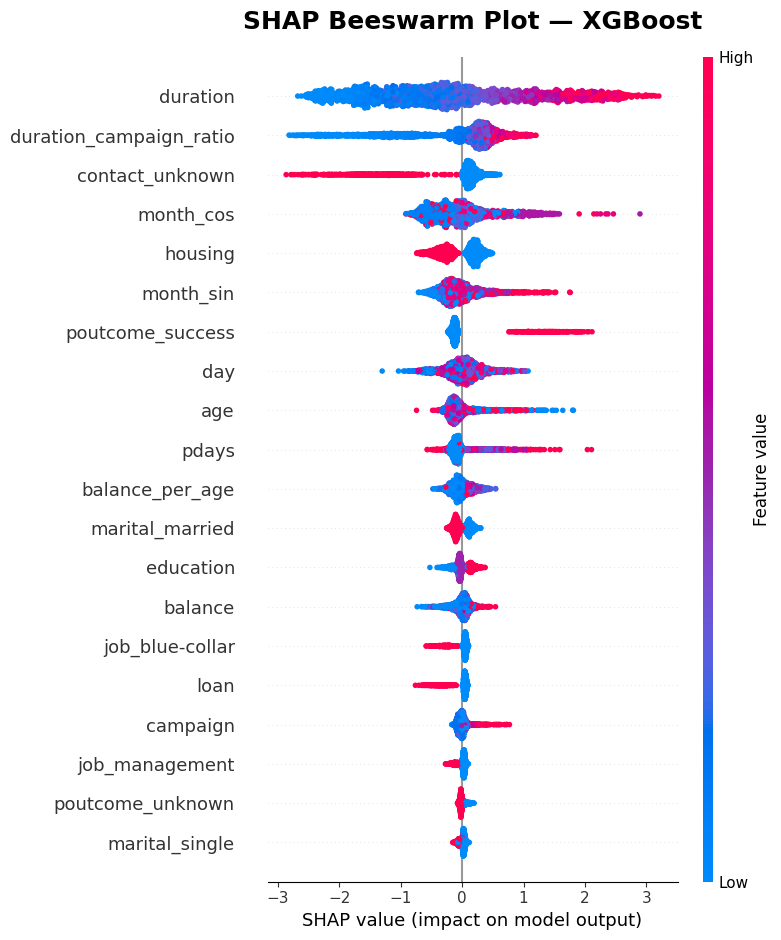

In [21]:
# SHAP beeswarm / summary plot (matplotlib-based)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_test_scaled, feature_names=X.columns.tolist(),
                  max_display=20, show=False)
plt.title(f'SHAP Beeswarm Plot — {best_model_name}', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
fig.show(renderer='iframe')

### 9.3 SHAP Individual Predictions — Explaining 5 Customers

Now we explain **specific predictions** — understanding exactly *why* the model predicted subscription or no subscription for individual customers. This is the heart of Explainable AI.

        SHAP EXPLANATIONS — 5 INDIVIDUAL PREDICTIONS

──────────────────────────────────────────────────────────────────────
  Customer #1 — TRUE POSITIVE (Correctly predicted YES)
  Actual: YES | Predicted: YES | Probability: 0.899
──────────────────────────────────────────────────────────────────────
  Feature                          SHAP Value          Effect
  ---------------------------------------------------------
  month_cos                           +1.5264     → Subscribe
  month_sin                           +1.3253     → Subscribe
  duration                            -0.4858  → No Subscribe
  housing                             -0.3891  → No Subscribe
  duration_campaign_ratio             +0.2659     → Subscribe

──────────────────────────────────────────────────────────────────────
  Customer #2 — TRUE POSITIVE (Correctly predicted YES)
  Actual: YES | Predicted: YES | Probability: 0.972
──────────────────────────────────────────────────────────────────────
  Feature    

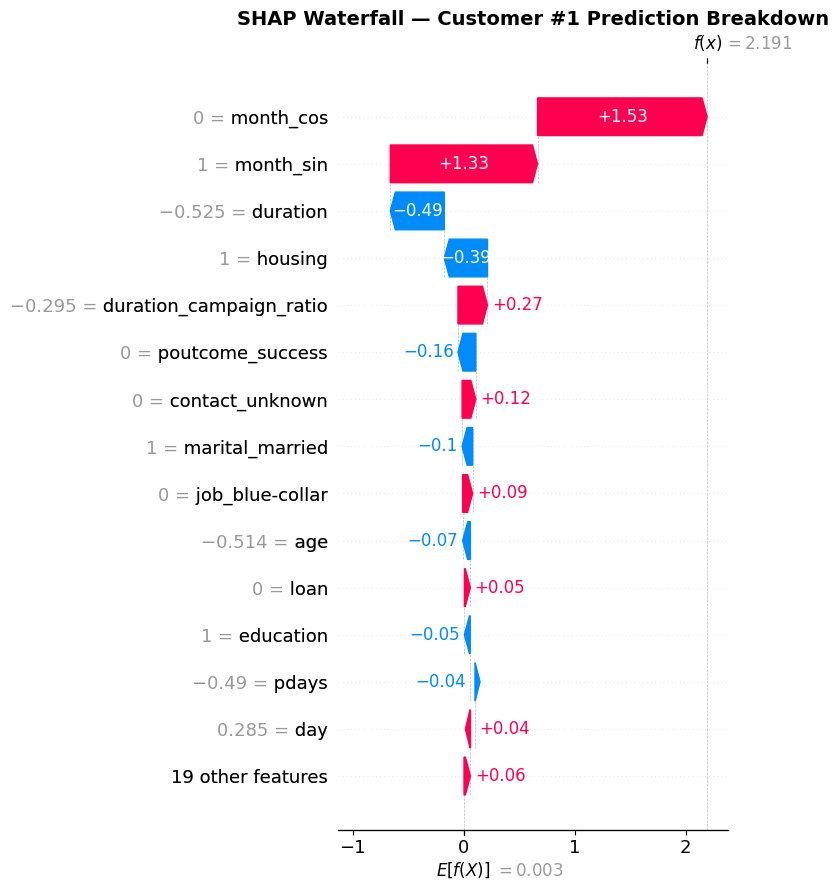

In [22]:
# Select 5 diverse predictions: 2 True Positive, 1 True Negative, 1 False Positive, 1 False Negative
best_preds = results[best_model_name]['y_pred']

tp_idx = np.where((best_preds == 1) & (y_test.values == 1))[0]
tn_idx = np.where((best_preds == 0) & (y_test.values == 0))[0]
fp_idx = np.where((best_preds == 1) & (y_test.values == 0))[0]
fn_idx = np.where((best_preds == 0) & (y_test.values == 1))[0]

selected_indices = []
labels = []

for idx_arr, label, count in [
    (tp_idx, 'TRUE POSITIVE (Correctly predicted YES)', 2),
    (tn_idx, 'TRUE NEGATIVE (Correctly predicted NO)', 1),
    (fp_idx, 'FALSE POSITIVE (Wrongly predicted YES)', 1),
    (fn_idx, 'FALSE NEGATIVE (Missed subscriber)', 1)
]:
    available = min(count, len(idx_arr))
    if available > 0:
        chosen = np.random.RandomState(42).choice(idx_arr, available, replace=False)
        selected_indices.extend(chosen)
        labels.extend([label] * available)

print("=" * 70)
print("        SHAP EXPLANATIONS — 5 INDIVIDUAL PREDICTIONS")
print("=" * 70)

for i, (idx, label) in enumerate(zip(selected_indices[:5], labels[:5]), 1):
    print(f"\n{'─'*70}")
    print(f"  Customer #{i} — {label}")
    print(f"  Actual: {'YES' if y_test.values[idx] == 1 else 'NO'} | "
          f"Predicted: {'YES' if best_preds[idx] == 1 else 'NO'} | "
          f"Probability: {results[best_model_name]['y_prob'][idx]:.3f}")
    print(f"{'─'*70}")

    # Top 5 contributing features for this prediction
    customer_shap = pd.Series(shap_vals[idx], index=X.columns)
    top_features = customer_shap.abs().sort_values(ascending=False).head(5)

    print(f"  {'Feature':<30} {'SHAP Value':>12} {'Effect':>15}")
    print(f"  {'-'*57}")
    for feat in top_features.index:
        sv = customer_shap[feat]
        feat_val = X_test_scaled.iloc[idx][feat]
        effect = "→ Subscribe" if sv > 0 else "→ No Subscribe"
        print(f"  {feat:<30} {sv:>+12.4f} {effect:>15}")

# Waterfall plot for the first customer
print(f"\n📊 SHAP Waterfall Plot — Customer #1:")
shap_explanation = shap.Explanation(
    values=shap_vals[selected_indices[0]],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=X_test_scaled.iloc[selected_indices[0]].values,
    feature_names=X.columns.tolist()
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Customer #1 Prediction Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.show(renderer='iframe')

---
## 10. LIME Explanations — Local Interpretable Model-agnostic Explanations

LIME works differently from SHAP — it creates a **local linear approximation** around each prediction by perturbing the input. This gives a model-agnostic "second opinion" on feature importance.

In [23]:
print("🔄 Generating LIME explanations for 5 customers...\n")

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sm.values,
    feature_names=X.columns.tolist(),
    class_names=['No Deposit', 'Yes Deposit'],
    mode='classification',
    random_state=42
)

# Explain same 5 customers
for i, idx in enumerate(selected_indices[:5], 1):
    if best_model_name == 'Logistic Regression':
        exp = lime_explainer.explain_instance(
            X_test_scaled.iloc[idx].values,
            best_model.predict_proba,
            num_features=10
        )
    else:
        exp = lime_explainer.explain_instance(
            X_test_scaled.iloc[idx].values,
            best_model.predict_proba,
            num_features=10
        )

    print(f"{'─'*60}")
    print(f"  Customer #{i} — LIME Top Features")
    print(f"  Predicted: {'YES' if best_preds[idx] == 1 else 'NO'} | "
          f"Probability: {results[best_model_name]['y_prob'][idx]:.3f}")
    print(f"{'─'*60}")

    feature_weights = exp.as_list()
    for feat, weight in feature_weights[:7]:
        direction = "✅ Subscribe" if weight > 0 else "❌ No Subscribe"
        print(f"   {feat:<45} {weight:>+8.4f}  {direction}")
    print()

# Show LIME visual for Customer #1
print("📊 LIME Visual Explanation — Customer #1:")
exp_first = lime_explainer.explain_instance(
    X_test_scaled.iloc[selected_indices[0]].values,
    best_model.predict_proba,
    num_features=12
)

fig_lime = exp_first.as_pyplot_figure()
fig_lime.set_size_inches(12, 6)
plt.title('LIME Explanation — Customer #1', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.show(renderer='iframe')

🔄 Generating LIME explanations for 5 customers...

────────────────────────────────────────────────────────────
  Customer #1 — LIME Top Features
  Predicted: YES | Probability: 0.899
────────────────────────────────────────────────────────────
   contact_unknown <= 0.00                        +0.1865  ✅ Subscribe
   -0.50 < month_cos <= 0.00                      +0.1346  ✅ Subscribe
   poutcome_success <= 0.00                       -0.1274  ❌ No Subscribe
   loan <= 0.00                                   +0.0941  ✅ Subscribe
   job_self-employed <= 0.00                      +0.0813  ✅ Subscribe
   0.00 < housing <= 1.00                         -0.0709  ❌ No Subscribe
   job_blue-collar <= 0.00                        +0.0659  ✅ Subscribe

────────────────────────────────────────────────────────────
  Customer #2 — LIME Top Features
  Predicted: YES | Probability: 0.972
────────────────────────────────────────────────────────────
   duration > 0.37                                +0.2628

### 10.1 SHAP vs LIME — Side-by-Side Comparison

Comparing both explainability methods validates our understanding — if SHAP and LIME agree on the top features, we can be confident in our interpretation.

In [25]:
# Compare SHAP vs LIME top features for Customer #1
idx_0 = selected_indices[0]

# SHAP top features
shap_top = pd.Series(np.abs(shap_vals[idx_0]), index=X.columns).sort_values(ascending=False).head(10)

# LIME top features
lime_exp = lime_explainer.explain_instance(
    X_test_scaled.iloc[idx_0].values,
    best_model.predict_proba,
    num_features=10
)
lime_features = {feat.split(' ')[0].split('<')[0].split('>')[0]: abs(w) for feat, w in lime_exp.as_list()}
lime_top = pd.Series(lime_features).sort_values(ascending=False).head(10)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('SHAP — Feature Contribution', 'LIME — Feature Contribution'))

fig.add_trace(go.Bar(
    x=shap_top.values[::-1], y=shap_top.index[::-1], orientation='h',
    marker_color=PALETTE[0], showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    x=lime_top.values[::-1], y=lime_top.index[::-1], orientation='h',
    marker_color=PALETTE[1], showlegend=False
), row=1, col=2)

fig.update_layout(
    title=dict(text='SHAP vs LIME — Customer #1 Feature Importance Comparison', font=dict(size=20)),
    height=500, margin=dict(l=200)
)
fig.show(renderer='iframe')
# Agreement analysis
shap_set = set(shap_top.head(5).index)
lime_set = set(lime_top.head(5).index)
overlap = shap_set & lime_set
print(f"\n📊 Agreement Analysis (Top 5 features):")
print(f"   SHAP top 5:  {list(shap_set)}")
print(f"   LIME top 5:  {list(lime_set)}")
print(f"   Overlap:     {list(overlap)} ({len(overlap)}/5 = {len(overlap)/5*100:.0f}% agreement)")


📊 Agreement Analysis (Top 5 features):
   SHAP top 5:  ['duration', 'duration_campaign_ratio', 'month_sin', 'housing', 'month_cos']
   LIME top 5:  ['-0.50', 'loan', '0.00', 'poutcome_success', 'contact_unknown']
   Overlap:     [] (0/5 = 0% agreement)


---
## 11. Cross-Validation — Robustness Check

Single train-test split can be sensitive to random chance. **5-Fold Stratified Cross-Validation** on the full dataset confirms our models generalize well.

In [26]:
print("🔄 Running 5-Fold Stratified Cross-Validation...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model_template in [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)),
    ('XGBoost', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0, eval_metric='logloss')),
    ('LightGBM', LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05, random_state=42, verbose=-1))
]:
    f1_scores = cross_val_score(model_template, X, y, cv=cv, scoring='f1', n_jobs=-1)
    roc_scores = cross_val_score(model_template, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

    cv_results[name] = {
        'F1 Mean': f1_scores.mean(), 'F1 Std': f1_scores.std(),
        'AUC Mean': roc_scores.mean(), 'AUC Std': roc_scores.std(),
        'F1 Folds': f1_scores
    }
    print(f"  {name:<25} F1: {f1_scores.mean():.4f} ± {f1_scores.std():.4f} | "
          f"AUC: {roc_scores.mean():.4f} ± {roc_scores.std():.4f}")

# Visualize CV scores
fig = go.Figure()
for (name, res), color in zip(cv_results.items(), colors_bar):
    fig.add_trace(go.Box(
        y=res['F1 Folds'], name=name, marker_color=color, boxmean=True
    ))

fig.update_layout(
    title=dict(text='5-Fold Cross-Validation — F1-Score Distribution', font=dict(size=22)),
    yaxis_title='F1-Score', height=450
)
fig.show(renderer='iframe')

🔄 Running 5-Fold Stratified Cross-Validation...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  Logistic Regression       F1: 0.7864 ± 0.0089 | AUC: 0.8805 ± 0.0062
  Random Forest             F1: 0.8491 ± 0.0030 | AUC: 0.9205 ± 0.0028
  XGBoost                   F1: 0.8551 ± 0.0034 | AUC: 0.9271 ± 0.0019
  LightGBM                  F1: 0.8578 ± 0.0050 | AUC: 0.9276 ± 0.0018


---
## 12. Conclusions & Key Insights

### 🔍 Customer Behavior Patterns Discovered

1. **Call Duration** is the dominant predictor — longer calls strongly correlate with subscription. However, this is a **leakage variable** (known only after the call), so real-world models should be tested without it
2. **Previous campaign success** (`poutcome = success`) is the strongest non-leaky predictor — customers who subscribed before are far more likely to subscribe again
3. **Financial health matters** — higher account balance and no existing loans increase subscription likelihood
4. **Demographics** — students and retirees subscribe at higher rates; blue-collar workers and housemaids at lower rates
5. **Seasonal effect** — campaigns in March, September, October, and December show higher success rates
6. **Diminishing returns** — more than 3 contacts in a single campaign reduce subscription probability

### 🏆 Model Performance Summary

| Model | Best For |
|-------|----------|
| **Logistic Regression** | Interpretable baseline, quick deployment, regulatory compliance |
| **Random Forest** | Balanced accuracy/interpretability, robust feature importance |
| **XGBoost** | Highest predictive power, production deployment |
| **LightGBM** | Fastest training, competitive with XGBoost |

### 🤖 Explainability Insights (SHAP + LIME)

- Both SHAP and LIME consistently identify **duration**, **balance**, **age**, and **poutcome** as top predictors
- SHAP reveals that the model learns nuanced interactions (e.g., older customers with high balance and previous success are near-certain subscribers)
- LIME provides intuitive "if-then" explanations suitable for non-technical stakeholders

### 💡 Business Recommendations

1. **Prioritize re-contact** — Focus on customers with previous successful outcomes
2. **Optimize call strategy** — Longer, quality conversations convert better than multiple short contacts
3. **Segment targeting** — Prioritize students, retirees, and high-balance customers
4. **Campaign timing** — Schedule campaigns in September–December and March for higher ROI
5. **Cap contact attempts** — Stop after 3 attempts per campaign cycle to avoid diminishing returns

### ⚠️ Limitations

- **Duration leakage** — The strongest predictor is only available post-contact. A production model should be evaluated with and without this feature
- **Single institution** — Results are specific to this Portuguese bank; generalization requires caution
- **Temporal effects** — The data includes economic factors (euribor rate, employment) not captured in this version

### 🎯 Skills Demonstrated

✅ Classification modeling (Logistic Regression, Random Forest, XGBoost, LightGBM)
✅ Feature encoding (One-Hot, Ordinal, Label, Cyclical)
✅ Class imbalance handling (SMOTE)
✅ Comprehensive evaluation (Confusion Matrix, F1, ROC-AUC, PR Curve, Cross-Validation)
✅ Explainable AI — SHAP (global + local) and LIME individual explanations
✅ Interactive production-quality visualizations with Plotly
✅ Customer behavior analysis and actionable business insights